# Rzutowanie współrzędnych ośrodków badania klinicznego do mapowania za pomocą PROC GPROJECT

## Podsumowanie wykonawcze

Zespół operacji klinicznych musi przedstawić geograficzny zasięg
wieloośrodkowego badania III fazy na płaskiej mapie. Ten notatnik
generuje syntetyczne współrzędne długości/szerokości geograficznej dla
ośrodków badawczych skupionych wokół pięciu regionalnych hubów w USA, a
następnie używa **PROC GPROJECT** do przekształcenia współrzędnych
sferycznych na wartości kartezjańskie X/Y za pomocą trzech metod
rzutowania (Albersa równopolowego, Lamberta wiernokątnego z
niestandardowymi równoleżnikami standardowymi i przycinaniem regionalnym
oraz gnomonicznego wyśrodkowanego na kontynentalnych USA), ilustrując, jak
wybór rzutowania i przycinania wpływa na mapę ośrodków.

## Źródła danych

| Zbiór danych | Wiersze | Kluczowe zmienne | Opis |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 hubów x 12 ośrodków) | `site_id` (ID, $8), `region` ($24), `x` (długość geograficzna, stopnie, wschód-dodatnia), `y` (szerokość geograficzna, stopnie), `enroll` (zrekrutowani uczestnicy), `segment` (id segmentu mapy) | Syntetyczne lokalizacje ośrodków badania klinicznego III fazy rozproszone wokół pięciu regionalnych hubów w USA (Zachód, Środkowy Zachód, Północny Wschód, Południe, Południowy Wschód) z wykorzystaniem szumu `rand('normal')` i liczby rekrutacji z `rand('poisson')` |

# Rzutowanie współrzędnych ośrodków badania klinicznego za pomocą PROC GPROJECT

Gdy sponsor prowadzi geograficznie rozproszone badanie III fazy, grupa
operacji klinicznych często chce jednej mapy pokazującej każdy ośrodek
badawczy, o rozmiarze lub kolorze zależnym od rekrutacji. Lokalizacje
ośrodków przychodzą jako **pary długość/szerokość geograficzna**, ale
płaska mapa wymaga **płaskich współrzędnych X/Y**. `PROC GPROJECT`
wykonuje tę konwersję ze sferycznych na kartezjańskie, stosując
rzutowanie kartograficzne, tak aby odległości i powierzchnie były
przedstawione sensownie.

W tym notatniku:

1. Generujemy syntetyczne współrzędne ośrodków skupionych wokół pięciu
   regionalnych hubów w USA.
2. Stosujemy domyślne rzutowanie **Albersa równopolowe**.
3. Stosujemy rzutowanie **Lamberta wiernokątne** z niestandardowymi
   równoleżnikami standardowymi i przycinamy do spójnych USA.
4. Stosujemy rzutowanie **gnomoniczne** wyśrodkowane na geograficznym
   środku kraju, zachowując oryginalne współrzędne dzięki `ASIS`.

Wszystko jest samodzielne: bez plików zewnętrznych, bez sieci.

## Krok 1 — Wygenerowanie syntetycznych współrzędnych ośrodków badania

Ustawiamy ziarno generatora liczb losowych za pomocą `call streaminit` dla
powtarzalności, a następnie umieszczamy 12 ośrodków wokół każdego z pięciu
miast-hubów regionalnych. Długości geograficzne są zapisane jako
wschód-dodatnie w stopniach (ujemne dla półkuli zachodniej), a szerokości
geograficzne w stopniach. Każdy wiersz niesie też liczbę rekrutacji i
zmienną `segment` (GPROJECT zachowuje kolumny inne niż współrzędne przez
cały proces rzutowania).

In [1]:
DANE trial_sites;
    CALL streaminit(20260531);
    DŁUGOŚĆ site_id $8 region $24;
    /* Pięć centrów regionalnych hubów w USA: długość geograficzna (wschód+), szerokość geograficzna */
    TABLICA clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    TABLICA clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    POWTÓRZ hub = 1 TO 5;
        JEŚLI hub = 1 WTEDY region = 'Zachód';
        PRZECIWNIE JEŚLI hub = 2 WTEDY region = 'Środkowy Zachód';
        PRZECIWNIE JEŚLI hub = 3 WTEDY region = 'Północny Wschód';
        PRZECIWNIE JEŚLI hub = 4 WTEDY region = 'Południe';
        PRZECIWNIE region = 'Południowy Wschód';
        POWTÓRZ s = 1 TO 12;
            site_id = cats('S', ZAPISZ(hub, z1.), ZAPISZ(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* długość geograficzna, stopnie */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* szerokość geograficzna, stopnie */
            enroll  = round(rand('poisson', 60));           /* zrekrutowani uczestnicy */
            segment = 1;
            WYJŚCIE;
        KONIEC;
    KONIEC;
    USUŃ hub s;
WYKONAJ;

PROCEDURA DRUKUJ DANE=trial_sites(obs=10) ETYKIETA;
    ETYKIETA site_id="ID ośrodka" region="Region" x="Długość geograficzna (X)" y="Szerokość geograficzna (Y)"
          enroll="Zrekrutowani uczestnicy" segment="Segment";
    TYTUŁ "Próbka syntetycznych ośrodków badania klinicznego (niezrzutowane lon/lat)";
WYKONAJ;

                       Próbka syntetycznych ośrodków badania klinicznego (niezrzutowane lon/lat)                        

  Obs   ID ośrodka   Region     Długość geograficzna (X)    Szerokość geograficzna (Y)  Zrekrutowani uczestnicy  Segment
    1  S101         Zachód               -121.6437232216                 37.7677668495                       65        1
    2  S102         Zachód               -120.7384024716                 37.5083287903                       61        1
    3  S103         Zachód               -121.5133780284                 37.8633933883                       72        1
    4  S104         Zachód               -121.2086817368                 38.7723343392                       68        1
    5  S105         Zachód               -121.0499572297                  37.175813806                       54        1
    6  S106         Zachód               -124.0531899967                  35.778231667                       72        1
    7  S107         Zachód     


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Krok 2 — Domyślne rzutowanie Albersa równopolowe

Stożkowe rzutowanie równopolowe **Albersa** jest domyślne dla GPROJECT i
sensownym wyborem dla mapy w skali kraju, gdzie zachowanie *względnej
powierzchni* ma znaczenie (np. porównywanie wielkości regionalnych
obszarów zasięgu).

Ponieważ nasze współrzędne są zapisane w **stopniach** z **długością
geograficzną wschód-dodatnią**, podajemy opcje `DEGREE` i `EASTLONG`.
Instrukcja `ID` wskazuje zmienną jednoznacznie identyfikującą każdą
jednostkę; zrzutowane współrzędne płaskie są zapisywane z powrotem do `x`
i `y` w zbiorze `OUT=`.

In [2]:
PROCEDURA GPROJECT DANE=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
WYKONAJ;

PROCEDURA DRUKUJ DANE=sites_albers(obs=10) ETYKIETA;
    ETYKIETA site_id="ID ośrodka" region="Region" x="Zrzutowane X" y="Zrzutowane Y"
          enroll="Zrekrutowani uczestnicy" segment="Segment";
    TYTUŁ "Ośrodki badania po rzutowaniu Albersa (równopolowym) (płaskie X/Y)";
WYKONAJ;

                       Próbka syntetycznych ośrodków badania klinicznego (niezrzutowane lon/lat)                        

                           Ośrodki badania po rzutowaniu Albersa (równopolowym) (płaskie X/Y)                           

  Obs   ID ośrodka   Region   Zrzutowane X  Zrzutowane Y  Zrekrutowani uczestnicy  Segment
    1  S101         Zachód    -0.346124731  0.0516986079                       65        1
    2  S102         Zachód   -0.3353644139  0.0440400181                       61        1
    3  S103         Zachód   -0.3439609675  0.0528501365                       72        1
    4  S104         Zachód   -0.3357513354   0.067213083                       68        1
    5  S105         Zachód   -0.3410170723  0.0394882801                       54        1
    6  S106         Zachód   -0.3879364507  0.0273340733                       72        1
    7  S107         Zachód   -0.3309127579  0.0711146305                       64        1
    8  S108         Zachód  


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Krok 3 — Rzutowanie Lamberta wiernokątne z niestandardowymi równoleżnikami i przycinaniem

Stożkowe rzutowanie wiernokątne **Lamberta** zachowuje *kształt i lokalne
kąty*, co jest preferowane, gdy mapa jest używana do nawigacji lub
nakładania cech kierunkowych. Dla spójnych USA konwencjonalne są
równoleżniki standardowe w pobliżu 33°N i 45°N, więc ustawiamy je jawnie
za pomocą `PARALLEL1=` i `PARALLEL2=`.

Ograniczamy też mapę do okna spójnych USA za pomocą opcji przycinania
`LATMIN=`, `LATMAX=`, `LONGMIN=` i `LONGMAX=`. Wszystkie ośrodki
wykraczające poza ten prostokąt długości/szerokości geograficznej są
odrzucane przed rzutowaniem, więc liczba obserwacji wyjściowych może być
niższa niż wejściowych.

In [3]:
PROCEDURA GPROJECT DANE=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
WYKONAJ;

PROCEDURA DRUKUJ DANE=sites_lambert(obs=10) ETYKIETA;
    ETYKIETA site_id="ID ośrodka" region="Region" x="Zrzutowane X" y="Zrzutowane Y"
          enroll="Zrekrutowani uczestnicy" segment="Segment";
    TYTUŁ "Ośrodki badania po rzutowaniu Lamberta (wiernokątnym) (przycięte do spójnych USA)";
WYKONAJ;

                           Ośrodki badania po rzutowaniu Albersa (równopolowym) (płaskie X/Y)                           

                   Ośrodki badania po rzutowaniu Lamberta (wiernokątnym) (przycięte do spójnych USA)                    

  Obs   ID ośrodka   Region   Zrzutowane X  Zrzutowane Y  Zrekrutowani uczestnicy  Segment
    1  S101         Zachód   -0.3473024124  0.0279382533                       65        1
    2  S102         Zachód   -0.3365626234  0.0201991247                       61        1
    3  S103         Zachód   -0.3451238364  0.0290365995                       72        1
    4  S104         Zachód   -0.3367881094  0.0430616123                       68        1
    5  S105         Zachód   -0.3422656751  0.0158037156                       54        1
    6  S106         Zachód   -0.3894389642  0.0046370991                       72        1
    7  S107         Zachód   -0.3319086764  0.0468276119                       64        1
    8  S109         Zachód  


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Krok 4 — Rzutowanie gnomoniczne wyśrodkowane na kraju, z zachowaniem oryginałów

Azymutalne rzutowanie **gnomoniczne** przedstawia każde koło wielkie jako
linię prostą, co jest przydatne, gdy chcemy rozumować o najkrótszej drodze
między ośrodkami (np. planując trasę podróży monitora badania).
Zniekształcenie rośnie wraz z odległością od bieguna rzutowania, więc
centrujemy biegun na geograficznym środku kontynentalnych USA za pomocą
`POLELAT=39` i `POLELONG=-98`.

Opcja `ASIS` mówi GPROJECT, aby zachować oryginalne, niezrzutowane
współrzędne obok wartości zrzutowanych, więc zbiór wyjściowy niesie
zarówno płaskie `X`/`Y`, jak i źródłowe `LONG`/`LAT` — przydatne do
łączenia metryk rekrutacji z powrotem do dowolnej przestrzeni
współrzędnych.

Instrukcja `PARMENTRY` jest pokazana jako alternatywny sposób
dostarczania parametrów rzutowania jako nadpisań klucz=wartość.

In [4]:
PROCEDURA GPROJECT DANE=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
WYKONAJ;

PROCEDURA DRUKUJ DANE=sites_gnomon(obs=10) ETYKIETA;
    ETYKIETA site_id="ID ośrodka" region="Region" x="Zrzutowane X" y="Zrzutowane Y"
          enroll="Zrekrutowani uczestnicy" segment="Segment";
    TYTUŁ "Ośrodki badania po rzutowaniu gnomonicznym (ASIS zachowuje oryginalne LONG/LAT)";
WYKONAJ;

                   Ośrodki badania po rzutowaniu Lamberta (wiernokątnym) (przycięte do spójnych USA)                    

                    Ośrodki badania po rzutowaniu gnomonicznym (ASIS zachowuje oryginalne LONG/LAT)                     

  Obs   ID ośrodka   Region   Zrzutowane X   Zrzutowane Y  Zrekrutowani uczestnicy  Segment             LONG            LAT
    1  S101         Zachód   -0.3343477981   0.0213614461                       65        1  -121.6437232216  37.7677668495
    2  S102         Zachód   -0.3221611694   0.0134152735                       61        1  -120.7384024716  37.5083287903
    3  S103         Zachód   -0.3319480803   0.0225717184                       72        1  -121.5133780284  37.8633933883
    4  S104         Zachód   -0.3230855797   0.0375741352                       68        1  -121.2086817368  38.7723343392
    5  S105         Zachód   -0.3283677206   0.0086308769                       54        1  -121.0499572297   37.175813806
    6  S106 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Krok 5 — Wyrenderowanie mapy zrzutowanych ośrodków

Cały sens rzutowania to narysowanie mapy. Podajemy zbiór `OUT=` Albersa
bezpośrednio do **PROC SGPLOT**, rysując płaskie `X`/`Y` i kolorując
każdy znacznik wg `region`. Ponieważ rzutowanie zachowało względną
geografię, pięć klastrów hubów ląduje w oczekiwanych narożnikach wykresu
— Zachód po lewej, Północny Wschód w prawym górnym rogu, Południe i
Południowy Wschód na dole — dając operacjom klinicznym wiernopowierzchniowy
zasięg opisany w podsumowaniu wykonawczym.

                    Ośrodki badania po rzutowaniu gnomonicznym (ASIS zachowuje oryginalne LONG/LAT)                     




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


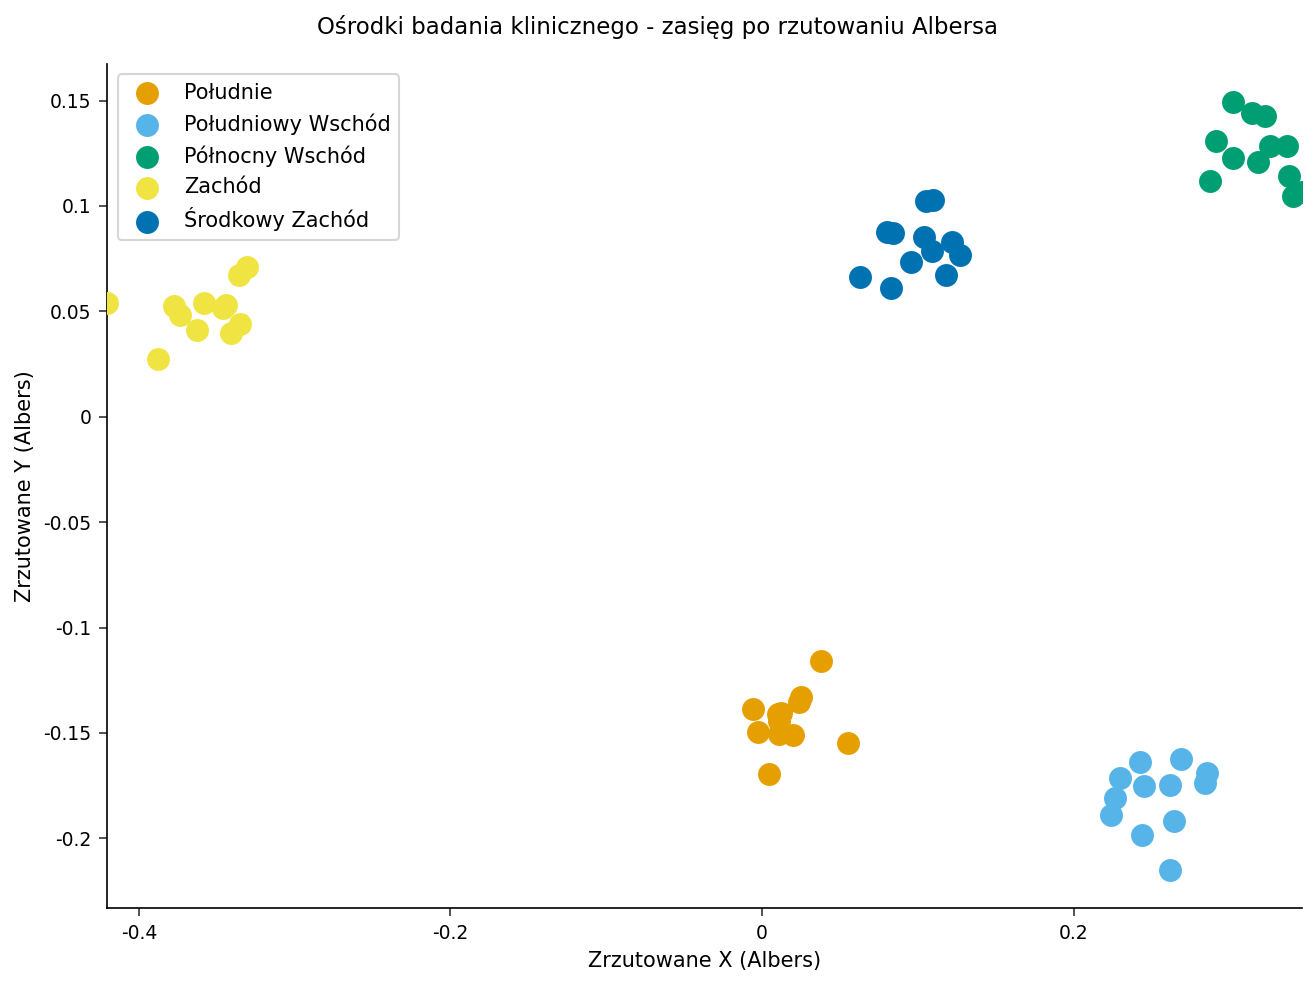

In [5]:
PROCEDURA SGPLOT DANE=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS ETYKIETA="Zrzutowane X (Albers)";
    YAXIS ETYKIETA="Zrzutowane Y (Albers)";
    TYTUŁ "Ośrodki badania klinicznego - zasięg po rzutowaniu Albersa";
WYKONAJ;

## Interpretacja wyników

- **Albers (krok 2)** przekształcił wszystkie 60 ośrodków na współrzędne
  płaskie, zachowując względną powierzchnię — klastry Zachód, Środkowy
  Zachód, Północny Wschód, Południe i Południowy Wschód zachowują swój
  proporcjonalny zasięg przestrzenny, co jest właściwą podstawą dla
  wiernopowierzchniowej mapy cieplnej rekrutacji.
- **Lambert z przycinaniem (krok 3)** zachował lokalny kształt i,
  stosując okno `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, odrzucił
  syntetyczne ośrodki, które znalazły się poza spójnymi USA — tutaj
  liczba spadła z 60 do 58, więc dwie współrzędne poza siatką, które
  inaczej rozciągnęłyby mapę, zostały usunięte przed rzutowaniem.
- **Gnomoniczne z `ASIS` (krok 4)** wyśrodkowało rzutowanie na wnętrzu
  kraju i, dzięki `ASIS`, wyprodukowało zbiór niosący zarówno zrzutowane
  `X`/`Y`, jak i oryginalne `LONG`/`LAT`. Koła wielkie pojawiają się jako
  linie proste, więc odległości w linii prostej na tej mapie przybliżają
  rzeczywiste najkrótsze ścieżki między ośrodkami.
- **Wyrenderowany zasięg (krok 5)** potwierdza, że rzutowanie zadziałało:
  wykreślenie Albersa `X`/`Y` wg regionu umieszcza pięć klastrów hubów w
  ich oczekiwanych narożnikach płaszczyzny — wiernopowierzchniową mapę
  ośrodków obiecaną w podsumowaniu wykonawczym.

**Wniosek dla operacji klinicznych:** rzutowanie nie jest kosmetyczne.
Wybierz **Albersa** dla wiernopowierzchniowej gęstości rekrutacji,
**Lamberta** dla wiernokształtnych nakładek z przycinaniem regionalnym,
oraz **gnomoniczne**, gdy odległość podróży między ośrodkami napędza
analizę. Jak pokazuje krok 5, zrzutowany zbiór `OUT=` trafia bezpośrednio
do PROC SGPLOT (lub PROC GMAP), aby wyrenderować ostateczną mapę
ośrodków.